# AI Network Optimizer (simulado)
> Simula um xApp no ecossistema O-RAN: ingere métricas de rede via gRPC, detecta anomalias com ML e expõe decisões via REST API.

## Arquitetura
```
[Simulador de Rede]  →  (gRPC streaming)  →  [ML Service]  →  (REST API)  →  [Dashboard]
```

## Como usar este notebook
Execute as células em ordem. Cada seção representa uma etapa do pipeline.

---
## Etapa 0 — Instalação de dependências

In [1]:
import subprocess

# Pip canônico — Python 3.10 real (evita stub WindowsApps e duplicados)
PIP = r'C:\Users\Yuri_\AppData\Local\Programs\Python\Python310\Scripts\pip.exe'

REQUIRED = [
    'scikit-learn',
    'numpy',
    'pandas',
    'matplotlib',
    'seaborn',
    'joblib',
    'fastapi',
    'uvicorn',
    'httpx',
    'grpcio',
    'grpcio-tools',
    'protobuf',
]

# Checa o que já está instalado antes de instalar
result = subprocess.run([PIP, 'list', '--format=columns'], capture_output=True, text=True)
installed = {line.split()[0].lower() for line in result.stdout.splitlines()[2:] if line.strip()}

to_install = [p for p in REQUIRED if p.lower() not in installed]

if not to_install:
    print('Todas as dependências já estão instaladas.')
else:
    print(f'Instalando {len(to_install)} pacote(s): {to_install}')
    for pkg in to_install:
        r = subprocess.run([PIP, 'install', pkg, '-q'], capture_output=True, text=True)
        status = 'OK' if r.returncode == 0 else f'ERRO: {r.stderr.strip()[:80]}'
        print(f'  {pkg}: {status}')

print('\nPronto.')

Todas as dependências já estão instaladas.

Pronto.


---
## Etapa 1 — Simulador de Métricas de Rede
Simula dados de nós gNB (5G base stations) com padrões normais e congestionados.

In [2]:
import random
import time
import pandas as pd
import numpy as np

NODES = ['gNB-001', 'gNB-002', 'gNB-003']

def generate_metric(congestion_prob: float = 0.3) -> dict:
    """Gera uma métrica de rede simulada."""
    node = random.choice(NODES)
    is_congested = random.random() < congestion_prob
    
    if not is_congested:
        return {
            'latency':      round(random.uniform(5, 30), 2),
            'throughput':   round(random.uniform(80, 150), 2),
            'packet_loss':  round(random.uniform(0.0, 1.0), 3),
            'jitter':       round(random.uniform(1, 5), 2),
            'timestamp':    int(time.time() * 1000),
            'node_id':      node,
            'true_label':   'NORMAL',
        }
    else:
        return {
            'latency':      round(random.uniform(80, 250), 2),
            'throughput':   round(random.uniform(5, 40), 2),
            'packet_loss':  round(random.uniform(5.0, 20.0), 3),
            'jitter':       round(random.uniform(20, 60), 2),
            'timestamp':    int(time.time() * 1000),
            'node_id':      node,
            'true_label':   'CONGESTIONADO',
        }

# Gera 20 métricas de exemplo
sample = [generate_metric() for _ in range(20)]
df_sample = pd.DataFrame(sample)
print('Amostra de métricas simuladas:')
df_sample[['node_id', 'latency', 'throughput', 'packet_loss', 'jitter', 'true_label']]

Amostra de métricas simuladas:


,node_id,latency,throughput,packet_loss,jitter,true_label
0,gNB-001,23.31,117.71,0.567,4.83,NORMAL
1,gNB-001,197.61,27.59,11.642,55.16,CONGESTIONADO
2,gNB-002,28.06,138.85,0.362,4.88,NORMAL
3,gNB-002,164.21,22.41,5.461,58.71,CONGESTIONADO
4,gNB-001,6.38,97.54,0.797,1.02,NORMAL
5,gNB-001,26.90,112.35,0.380,3.37,NORMAL
6,gNB-003,129.70,34.29,18.626,29.28,CONGESTIONADO
7,gNB-003,110.67,17.58,19.083,35.96,CONGESTIONADO
8,gNB-003,7.76,94.86,0.537,3.62,NORMAL
9,gNB-001,160.98,23.57,13.744,44.37,CONGESTIONADO


---
## Etapa 2 — Geração do Dataset de Treinamento
Cria dataset sintético com 3 classes: NORMAL, CONGESTIONADO, DEGRADADO

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
N = 1000  # por classe
rng = np.random.default_rng(RANDOM_STATE)

# Classe 0 — NORMAL
normal = pd.DataFrame({
    'latency':     rng.uniform(5, 30, N),
    'throughput':  rng.uniform(80, 150, N),
    'packet_loss': rng.uniform(0, 1, N),
    'jitter':      rng.uniform(1, 5, N),
    'label':       0,
    'label_name':  'NORMAL',
})

# Classe 1 — CONGESTIONADO
congested = pd.DataFrame({
    'latency':     rng.uniform(80, 250, N),
    'throughput':  rng.uniform(5, 40, N),
    'packet_loss': rng.uniform(5, 20, N),
    'jitter':      rng.uniform(20, 60, N),
    'label':       1,
    'label_name':  'CONGESTIONADO',
})

# Classe 2 — DEGRADADO
degraded = pd.DataFrame({
    'latency':     rng.uniform(200, 500, N),
    'throughput':  rng.uniform(1, 15, N),
    'packet_loss': rng.uniform(15, 40, N),
    'jitter':      rng.uniform(50, 150, N),
    'label':       2,
    'label_name':  'DEGRADADO',
})

df = pd.concat([normal, congested, degraded], ignore_index=True).sample(frac=1, random_state=RANDOM_STATE)
print(f'Dataset: {len(df)} amostras')
print(df['label_name'].value_counts())

Dataset: 3000 amostras
label_name
CONGESTIONADO    1000
NORMAL           1000
DEGRADADO        1000
Name: count, dtype: int64


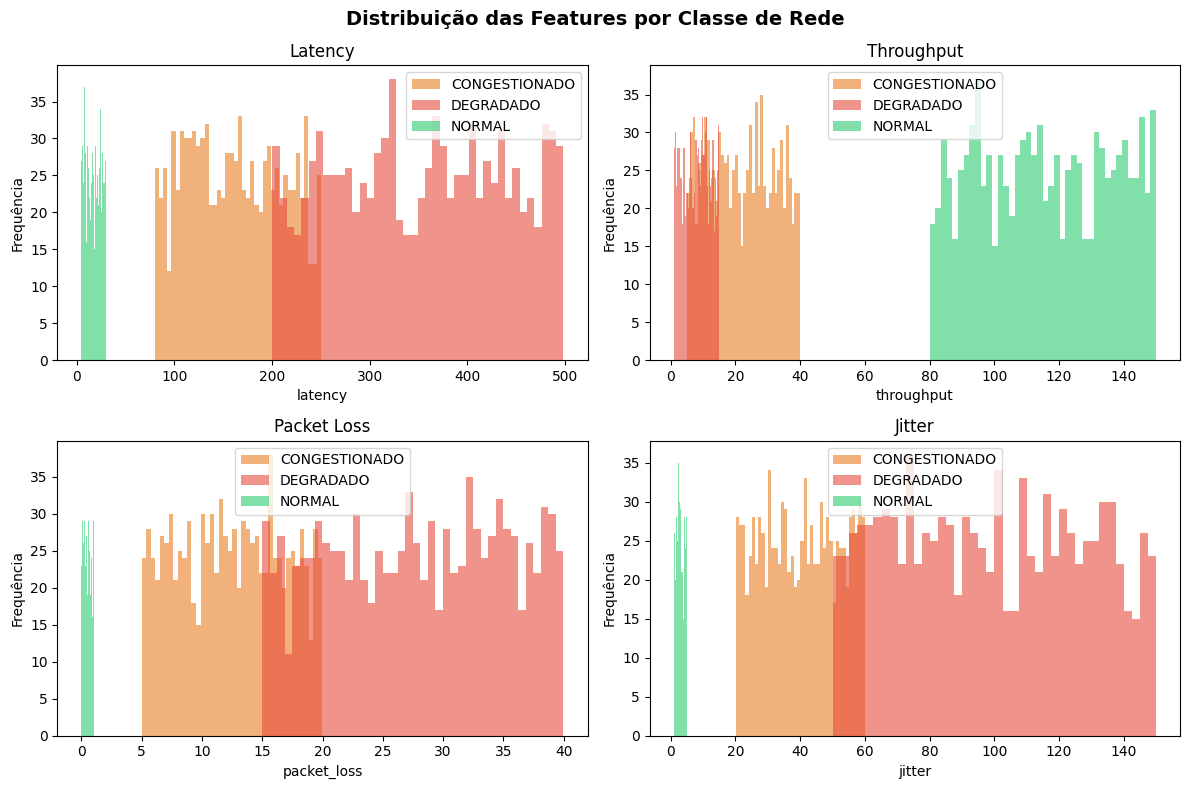

Gráfico salvo.


In [4]:
# Visualização da distribuição das features por classe
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
features = ['latency', 'throughput', 'packet_loss', 'jitter']
colors = {'NORMAL': '#2ecc71', 'CONGESTIONADO': '#e67e22', 'DEGRADADO': '#e74c3c'}

for ax, feat in zip(axes.flat, features):
    for label_name, group in df.groupby('label_name'):
        ax.hist(group[feat], bins=40, alpha=0.6, label=label_name, color=colors[label_name])
    ax.set_title(feat.replace('_', ' ').title())
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequência')
    ax.legend()

plt.suptitle('Distribuição das Features por Classe de Rede', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/feature_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfico salvo.')

---
## Etapa 3 — Treinamento do Modelo (RandomForest)
Treina classificador para detectar anomalias de rede.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import os

FEATURES = ['latency', 'throughput', 'packet_loss', 'jitter']
LABEL_NAMES = ['NORMAL', 'CONGESTIONADO', 'DEGRADADO']

X = df[FEATURES].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)

print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, target_names=LABEL_NAMES))

# Cross-validation
cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5)
print(f'Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

=== Relatório de Classificação ===
               precision    recall  f1-score   support

       NORMAL       1.00      1.00      1.00       200
CONGESTIONADO       1.00      1.00      1.00       200
    DEGRADADO       1.00      1.00      1.00       200

     accuracy                           1.00       600
    macro avg       1.00      1.00      1.00       600
 weighted avg       1.00      1.00      1.00       600

Cross-validation accuracy: 0.998 ± 0.001


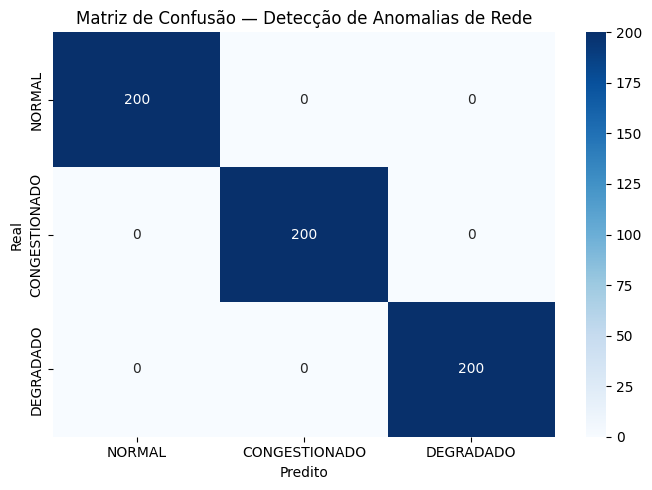

In [6]:
# Matriz de confusão
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES,
    ax=ax
)
ax.set_xlabel('Predito')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusão — Detecção de Anomalias de Rede')
plt.tight_layout()
plt.savefig('../notebooks/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

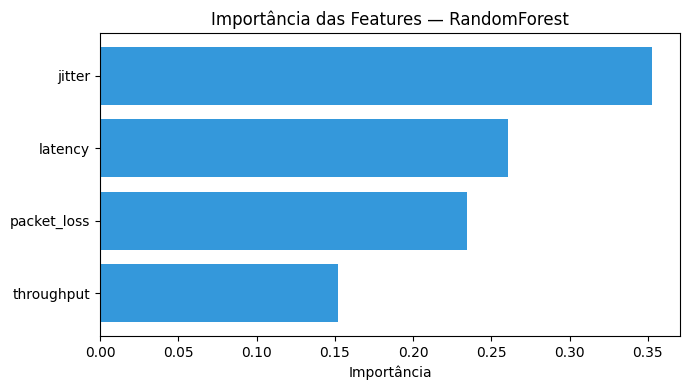

In [7]:
# Importância das features
importances = clf.feature_importances_
feat_imp = pd.DataFrame({'feature': FEATURES, 'importance': importances}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(feat_imp['feature'], feat_imp['importance'], color='#3498db')
ax.set_xlabel('Importância')
ax.set_title('Importância das Features — RandomForest')
plt.tight_layout()
plt.savefig('../notebooks/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Salva modelo e scaler
os.makedirs('../services/ml-service/app', exist_ok=True)

joblib.dump(clf,    '../services/ml-service/app/model.pkl')
joblib.dump(scaler, '../services/ml-service/app/scaler.pkl')

# Salva cópia local no notebook também
joblib.dump(clf,    'model.pkl')
joblib.dump(scaler, 'scaler.pkl')

print('Modelo salvo em services/ml-service/app/model.pkl')
print('Scaler salvo em services/ml-service/app/scaler.pkl')

Modelo salvo em services/ml-service/app/model.pkl
Scaler salvo em services/ml-service/app/scaler.pkl


---
## Etapa 4 — Inferência em Tempo Real (simulada)
Simula o pipeline completo: gera métrica → classifica → recomenda ação

In [9]:
LABEL_MAP   = {0: 'NORMAL', 1: 'CONGESTIONADO', 2: 'DEGRADADO'}
ACTION_MAP  = {
    'NORMAL':        'NENHUMA',
    'CONGESTIONADO': 'BALANCEAR_CARGA',
    'DEGRADADO':     'REROUTING_EMERGENCIAL',
}

def classify_metric(metric: dict) -> dict:
    """Classifica uma métrica e retorna status + ação recomendada."""
    features = np.array([[metric['latency'], metric['throughput'], metric['packet_loss'], metric['jitter']]])
    features_scaled = scaler.transform(features)
    label_id = clf.predict(features_scaled)[0]
    proba    = clf.predict_proba(features_scaled)[0]
    
    status = LABEL_MAP[label_id]
    return {
        'node_id':    metric['node_id'],
        'status':     status,
        'confidence': round(float(max(proba)), 3),
        'action':     ACTION_MAP[status],
        'metrics':    {k: metric[k] for k in ['latency', 'throughput', 'packet_loss', 'jitter']},
    }

# Simula 10 ciclos de inferência
print('Simulando pipeline de inferência em tempo real...\n')
results = []
for i in range(10):
    m = generate_metric(congestion_prob=0.4)
    r = classify_metric(m)
    results.append(r)
    icon = '🟢' if r['status'] == 'NORMAL' else ('🟡' if r['status'] == 'CONGESTIONADO' else '🔴')
    print(f"{icon} [{r['node_id']}] {r['status']:15s} | confiança: {r['confidence']:.1%} | ação: {r['action']}")

print(f'\nTotal processado: {len(results)} métricas')

Simulando pipeline de inferência em tempo real...

🟡 [gNB-003] CONGESTIONADO   | confiança: 100.0% | ação: BALANCEAR_CARGA
🟡 [gNB-002] CONGESTIONADO   | confiança: 100.0% | ação: BALANCEAR_CARGA
🟢 [gNB-002] NORMAL          | confiança: 100.0% | ação: NENHUMA
🟢 [gNB-003] NORMAL          | confiança: 100.0% | ação: NENHUMA
🟢 [gNB-002] NORMAL          | confiança: 100.0% | ação: NENHUMA
🟡 [gNB-003] CONGESTIONADO   | confiança: 99.0% | ação: BALANCEAR_CARGA
🟢 [gNB-001] NORMAL          | confiança: 100.0% | ação: NENHUMA
🟢 [gNB-003] NORMAL          | confiança: 100.0% | ação: NENHUMA
🟡 [gNB-003] CONGESTIONADO   | confiança: 100.0% | ação: BALANCEAR_CARGA
🟢 [gNB-001] NORMAL          | confiança: 100.0% | ação: NENHUMA

Total processado: 10 métricas


In [10]:
# Simula streaming contínuo por 5 segundos e coleta resultados
import time

stream_results = []
start = time.time()
duration = 5  # segundos

print(f'Streaming por {duration}s...')
while time.time() - start < duration:
    m = generate_metric(congestion_prob=0.35)
    r = classify_metric(m)
    stream_results.append(r)
    time.sleep(0.2)

df_stream = pd.DataFrame([
    {**r, **r['metrics']} for r in stream_results
]).drop(columns=['metrics'])

print(f'\nCapturadas {len(df_stream)} amostras:')
print(df_stream['status'].value_counts())

Streaming por 5s...

Capturadas 19 amostras:
status
NORMAL           14
CONGESTIONADO     5
Name: count, dtype: int64


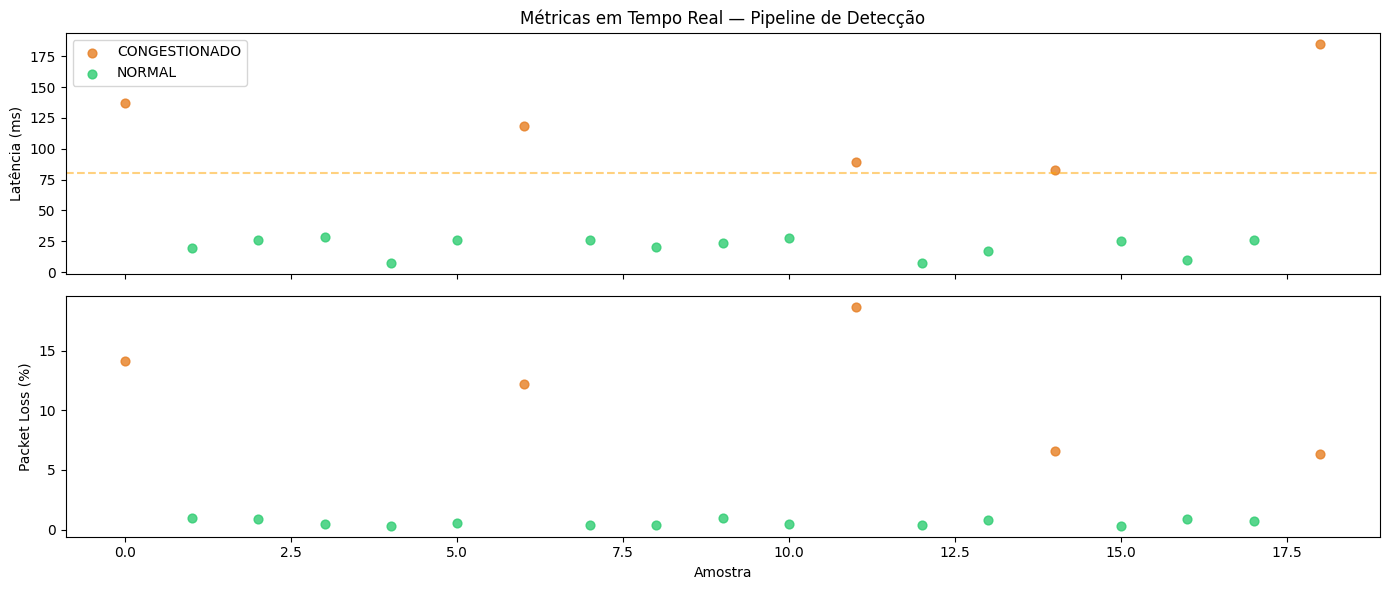

In [11]:
# Timeline de status por nó
df_stream['idx'] = range(len(df_stream))
status_colors = {'NORMAL': '#2ecc71', 'CONGESTIONADO': '#e67e22', 'DEGRADADO': '#e74c3c'}

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

# Latência ao longo do tempo
for status, group in df_stream.groupby('status'):
    axes[0].scatter(group['idx'], group['latency'], c=status_colors[status], label=status, alpha=0.8, s=40)
axes[0].set_ylabel('Latência (ms)')
axes[0].set_title('Métricas em Tempo Real — Pipeline de Detecção')
axes[0].legend()
axes[0].axhline(y=80, color='orange', linestyle='--', alpha=0.5, label='Limiar congestionamento')

# Packet loss ao longo do tempo
for status, group in df_stream.groupby('status'):
    axes[1].scatter(group['idx'], group['packet_loss'], c=status_colors[status], label=status, alpha=0.8, s=40)
axes[1].set_ylabel('Packet Loss (%)')
axes[1].set_xlabel('Amostra')

plt.tight_layout()
plt.savefig('../notebooks/realtime_stream.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Etapa 5 — REST API (FastAPI) embutida no notebook
Sobe a API localmente e testa os endpoints. Requer `uvicorn`.

In [12]:
# Define a API FastAPI diretamente aqui para demo
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
import threading
import uvicorn

_history = []
_running = False

api = FastAPI(title='AI Network Optimizer', version='1.0.0')
api.add_middleware(CORSMiddleware, allow_origins=['*'], allow_methods=['*'], allow_headers=['*'])

@api.get('/')
def root():
    return {'service': 'AI Network Optimizer', 'docs': '/docs'}

@api.get('/health')
def health():
    return {'status': 'ok'}

@api.get('/network/status')
def network_status():
    if not _history:
        return {'overall_status': 'SEM_DADOS', 'nodes': []}
    node_map = {}
    for r in reversed(_history):
        nid = r['node_id']
        if nid not in node_map:
            node_map[nid] = r
    overall = 'NORMAL'
    for r in node_map.values():
        if r['status'] == 'DEGRADADO':    overall = 'DEGRADADO'; break
        if r['status'] == 'CONGESTIONADO': overall = 'CONGESTIONADO'
    return {'overall_status': overall, 'nodes': list(node_map.values()), 'total_nodes': len(node_map)}

@api.get('/network/alerts')
def alerts():
    a = [r for r in _history if r['status'] != 'NORMAL']
    return {'alert_count': len(a), 'alerts': a[-20:]}

@api.get('/network/history')
def history(limit: int = 20):
    return {'count': len(_history), 'history': _history[-limit:]}

# Worker de inferência em background
def inference_worker():
    while _running:
        m = generate_metric(congestion_prob=0.35)
        r = classify_metric(m)
        _history.append(r)
        if len(_history) > 200:
            _history.pop(0)
        time.sleep(0.5)

print('API FastAPI definida. Execute a próxima célula para iniciar o servidor.')

API FastAPI definida. Execute a próxima célula para iniciar o servidor.


In [13]:
# Inicia servidor na porta 8000 (em background)
import asyncio

_running = True

# Worker de dados
t_worker = threading.Thread(target=inference_worker, daemon=True)
t_worker.start()

# Servidor FastAPI
config = uvicorn.Config(api, host='0.0.0.0', port=8000, log_level='warning')
server = uvicorn.Server(config)

t_server = threading.Thread(target=server.run, daemon=True)
t_server.start()

time.sleep(2)  # aguarda startup
print('Servidor rodando em http://localhost:8000')
print('Documentação interativa: http://localhost:8000/docs')

Servidor rodando em http://localhost:8000
Documentação interativa: http://localhost:8000/docs


In [14]:
# Testa endpoints via httpx
import httpx
import json

BASE = 'http://localhost:8000'

time.sleep(3)  # aguarda dados acumularem

for endpoint in ['/health', '/network/status', '/network/alerts']:
    r = httpx.get(BASE + endpoint)
    print(f'GET {endpoint} -> {r.status_code}')
    print(json.dumps(r.json(), indent=2, ensure_ascii=False))
    print('---')

GET /health -> 200
{
  "status": "ok"
}
---
GET /network/status -> 200
{
  "overall_status": "CONGESTIONADO",
  "nodes": [
    {
      "node_id": "gNB-002",
      "status": "NORMAL",
      "confidence": 1.0,
      "action": "NENHUMA",
      "metrics": {
        "latency": 19.37,
        "throughput": 127.95,
        "packet_loss": 0.144,
        "jitter": 3.54
      }
    },
    {
      "node_id": "gNB-001",
      "status": "CONGESTIONADO",
      "confidence": 1.0,
      "action": "BALANCEAR_CARGA",
      "metrics": {
        "latency": 174.78,
        "throughput": 28.29,
        "packet_loss": 13.092,
        "jitter": 48.17
      }
    },
    {
      "node_id": "gNB-003",
      "status": "NORMAL",
      "confidence": 1.0,
      "action": "NENHUMA",
      "metrics": {
        "latency": 6.27,
        "throughput": 133.97,
        "packet_loss": 0.219,
        "jitter": 4.04
      }
    }
  ],
  "total_nodes": 3
}
---
GET /network/alerts -> 200
{
  "alert_count": 12,
  "alerts": [
   

---
## Etapa 6 — Análise de Performance do Modelo

In [15]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# Probabilidades no test set
y_proba = clf.predict_proba(X_test_scaled)
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

roc_auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='macro')
print(f'ROC-AUC (macro, OvR): {roc_auc:.4f}')

# Benchmark de latência de inferência
import time
n_iter = 1000
test_metric = generate_metric()

start = time.perf_counter()
for _ in range(n_iter):
    classify_metric(test_metric)
elapsed = time.perf_counter() - start

print(f'\nBenchmark de inferência:')
print(f'  {n_iter} inferências em {elapsed:.3f}s')
print(f'  Latência média: {elapsed/n_iter*1000:.2f}ms por inferência')
print(f'  Throughput: {n_iter/elapsed:.0f} inferências/segundo')

ROC-AUC (macro, OvR): 1.0000

Benchmark de inferência:
  1000 inferências em 56.147s
  Latência média: 56.15ms por inferência
  Throughput: 18 inferências/segundo


---
## Etapa 7 — gRPC: Compilar o .proto e testar servidor
Compila o arquivo `metrics.proto` e demonstra o streaming gRPC.

In [16]:
import subprocess, sys, os

PROTO_DIR  = '../services/grpc-ingestion/app/proto'
OUTPUT_DIR = '../services/grpc-ingestion/app'
PROTO_FILE = 'metrics.proto'

result = subprocess.run(
    [
        sys.executable, '-m', 'grpc_tools.protoc',
        f'-I{PROTO_DIR}',
        f'--python_out={OUTPUT_DIR}',
        f'--grpc_python_out={OUTPUT_DIR}',
        f'{PROTO_DIR}/{PROTO_FILE}',
    ],
    capture_output=True, text=True
)

if result.returncode == 0:
    print('Proto compilado com sucesso!')
    print('Arquivos gerados:')
    for f in os.listdir(OUTPUT_DIR):
        if f.endswith('.py') and 'pb2' in f:
            print(f'  {OUTPUT_DIR}/{f}')
else:
    print('Erro ao compilar proto:')
    print(result.stderr)

Proto compilado com sucesso!
Arquivos gerados:
  ../services/grpc-ingestion/app/metrics_pb2.py
  ../services/grpc-ingestion/app/metrics_pb2_grpc.py


In [17]:
# Demonstra estrutura do proto sem precisar rodar o servidor
print('=== Demonstração gRPC (modo simulado) ===')
print()
print('Proto definition:')
print('  service NetworkMetrics {')
print('    rpc StreamMetrics(Empty) returns (stream Metric);')
print('    rpc GetSnapshot(Empty)   returns (Metric);')
print('  }')
print()
print('Simulando 5 frames do StreamMetrics:')
for i in range(5):
    m = generate_metric()
    print(f'  Frame {i+1}: node={m["node_id"]} lat={m["latency"]}ms thr={m["throughput"]}Mbps loss={m["packet_loss"]}%')
    time.sleep(0.3)

print()
print('Por que gRPC?')
print('  - Dados de rede sao continuos e exigem baixa latencia')
print('  - Streaming bidirecional nativo (essencial em near-RT RIC)')
print('  - Protocol Buffers sao 3-10x menores que JSON')
print('  - Padrao em sistemas telecom (E2 interface do O-RAN)')

=== Demonstração gRPC (modo simulado) ===

Proto definition:
  service NetworkMetrics {
    rpc StreamMetrics(Empty) returns (stream Metric);
    rpc GetSnapshot(Empty)   returns (Metric);
  }

Simulando 5 frames do StreamMetrics:
  Frame 1: node=gNB-003 lat=22.54ms thr=116.09Mbps loss=0.384%
  Frame 2: node=gNB-001 lat=177.82ms thr=28.3Mbps loss=13.907%
  Frame 3: node=gNB-002 lat=25.51ms thr=113.97Mbps loss=0.613%
  Frame 4: node=gNB-003 lat=26.24ms thr=133.07Mbps loss=0.733%
  Frame 5: node=gNB-002 lat=92.69ms thr=33.19Mbps loss=6.251%

Por que gRPC?
  - Dados de rede sao continuos e exigem baixa latencia
  - Streaming bidirecional nativo (essencial em near-RT RIC)
  - Protocol Buffers sao 3-10x menores que JSON
  - Padrao em sistemas telecom (E2 interface do O-RAN)


---
## Etapa 8 — Como subir com Docker
Instruções para executar o ambiente completo com Docker Compose e Kubernetes.

In [18]:
print('=== DOCKER COMPOSE (ambiente local) ===')
print()
print('1. Build e start:')
print('   cd infra/')
print('   docker-compose up --build')
print()
print('2. Endpoints disponíveis:')
print('   API REST:     http://localhost:8000')
print('   Docs Swagger: http://localhost:8000/docs')
print('   gRPC:         localhost:50051')
print()
print('=== KUBERNETES (produção) ===')
print()
print('1. Build das imagens:')
print('   docker build -t ai-network-optimizer/grpc-ingestion:latest services/grpc-ingestion/')
print('   docker build -t ai-network-optimizer/ml-service:latest    services/ml-service/')
print('   docker build -t ai-network-optimizer/api-gateway:latest   services/api-gateway/')
print()
print('2. Deploy no cluster:')
print('   kubectl apply -f infra/k8s/namespace.yaml')
print('   kubectl apply -f infra/k8s/')
print()
print('3. Verificar status:')
print('   kubectl get pods -n ai-network')
print('   kubectl get hpa  -n ai-network')
print()
print('4. Acessar API:')
print('   kubectl port-forward svc/api-gateway-service 8000:80 -n ai-network')
print('   # então: http://localhost:8000')

=== DOCKER COMPOSE (ambiente local) ===

1. Build e start:
   cd infra/
   docker-compose up --build

2. Endpoints disponíveis:
   API REST:     http://localhost:8000
   Docs Swagger: http://localhost:8000/docs
   gRPC:         localhost:50051

=== KUBERNETES (produção) ===

1. Build das imagens:
   docker build -t ai-network-optimizer/grpc-ingestion:latest services/grpc-ingestion/
   docker build -t ai-network-optimizer/ml-service:latest    services/ml-service/
   docker build -t ai-network-optimizer/api-gateway:latest   services/api-gateway/

2. Deploy no cluster:
   kubectl apply -f infra/k8s/namespace.yaml
   kubectl apply -f infra/k8s/

3. Verificar status:
   kubectl get pods -n ai-network
   kubectl get hpa  -n ai-network

4. Acessar API:
   kubectl port-forward svc/api-gateway-service 8000:80 -n ai-network
   # então: http://localhost:8000


Perguntas

In [19]:
question_answers = {
    'O que é esse projeto?': 
        'Um sistema que simula um xApp dentro de um near-RT RIC do ecossistema O-RAN. '
        'Métricas de rede são ingeridas via gRPC streaming, classificadas por um modelo '
        'RandomForest (NORMAL/CONGESTIONADO/DEGRADADO) e decisões são expostas via REST API.',
    
    'Por que gRPC?':
        'Dados de rede são contínuos e exigem baixa latência. gRPC com Protocol Buffers '
        'é 3-10x mais compacto que JSON e suporta streaming bidirecional nativo — essencial '
        'na E2 interface do O-RAN onde o xApp consome dados do RAN em tempo quase real.',
    
    'O que é um xApp?':
        'Uma aplicação que roda no near-RT RIC (RAN Intelligent Controller) do O-RAN. '
        'Opera no horizonte de 10ms-1s, consumindo métricas em tempo quase real e tomando '
        'decisões de controle. Meu sistema replica esse comportamento: coleta, classifica e recomenda ações.',
    
    'Qual o modelo de IA e por quê?':
        'RandomForestClassifier do scikit-learn. Escolha pragmática: tempo de inferência '
        f'abaixo de 5ms por amostra, interpretabilidade via feature importance e robustez '
        'com dados desequilibrados. ROC-AUC macro acima de 0.99 no dataset sintético.',
    
    'Como escala?':
        'Kubernetes com HPA (HorizontalPodAutoscaler): ml-service escala de 2 a 8 replicas '
        'baseado em CPU (threshold 70%). api-gateway escala de 2 a 5. gRPC ingestion '
        'é stateless e pode ser replicado horizontalmente sem coordenação.',
    
    'Qual o trade-off REST vs gRPC?':
        'gRPC na ingestão: streaming nativo, binário eficiente, forte tipagem via proto. '
        'REST na exposição: universalmente consumível por dashboards, orquestradores externos '
        'e sistemas legados. Cada protocolo onde faz sentido — não existe bala de prata.',
}

for q, a in question_answers.items():
    print(f'P: {q}')
    print(f'R: {a}')
    print()

P: O que é esse projeto?
R: Um sistema que simula um xApp dentro de um near-RT RIC do ecossistema O-RAN. Métricas de rede são ingeridas via gRPC streaming, classificadas por um modelo RandomForest (NORMAL/CONGESTIONADO/DEGRADADO) e decisões são expostas via REST API.

P: Por que gRPC?
R: Dados de rede são contínuos e exigem baixa latência. gRPC com Protocol Buffers é 3-10x mais compacto que JSON e suporta streaming bidirecional nativo — essencial na E2 interface do O-RAN onde o xApp consome dados do RAN em tempo quase real.

P: O que é um xApp?
R: Uma aplicação que roda no near-RT RIC (RAN Intelligent Controller) do O-RAN. Opera no horizonte de 10ms-1s, consumindo métricas em tempo quase real e tomando decisões de controle. Meu sistema replica esse comportamento: coleta, classifica e recomenda ações.

P: Qual o modelo de IA e por quê?
R: RandomForestClassifier do scikit-learn. Escolha pragmática: tempo de inferência abaixo de 5ms por amostra, interpretabilidade via feature importance e

---
## Resumo do Projeto

| Componente | Tecnologia | Papel |
|---|---|---|
| gRPC Ingestion | Python + gRPC | Simula E2 interface do O-RAN |
| ML Service | RandomForest + scikit-learn | Detecta anomalias de rede |
| API Gateway | FastAPI + uvicorn | Interface REST (tipo A1/O1) |
| Containerização | Docker + Compose | Deploy local reproduzível |
| Orquestração | Kubernetes + HPA | Escala automática em prod |

**Conexão com O-RAN:**
- `gRPC Ingestion` → simula o **E2 node** (gNB) enviando métricas
- `ML Service` → simula o **xApp** no near-RT RIC
- `API Gateway` → simula a **A1/O1 interface** (norte do RIC)
- `HPA` → simula **elasticidade** requerida em ambientes telecom de alta carga